In [1]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix

Matplotlib is building the font cache; this may take a moment.


In [2]:
df = pd.read_csv('train.csv')

print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (891, 12)

First 5 rows:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
# Keep only the columns we need
df = df[['Survived', 'Pclass', 'Sex', 'Age', 'Fare']].dropna()

# Encode Sex: male=0, female=1
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

print("Shape after cleaning:", df.shape)
print("\nSurvival distribution:")
print(df['Survived'].value_counts())

df.head()

Shape after cleaning: (714, 5)

Survival distribution:
Survived
0    424
1    290
Name: count, dtype: int64


,Survived,Pclass,Sex,Age,Fare
0,0,3,0,22.0,7.2500
1,1,1,1,38.0,71.2833
2,1,3,1,26.0,7.9250
3,1,1,1,35.0,53.1000
4,0,3,0,35.0,8.0500


In [ ]:
X = df[['Pclass', 'Sex', 'Age', 'Fare']]
y = df['Survived']

# Split — stratify keeps survival ratio same in train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale — critical for kNN so fare doesn't dominate age
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Training size:", X_train.shape)
print("Test size:    ", X_test.shape)

Training size: (571, 4)
Test size:     (143, 4)


In [5]:
algorithms = {
    'Brute Force': 'brute',
    'KD-Tree':     'kd_tree',
    'Ball Tree':   'ball_tree'
}

results = {}

print(f"{'Algorithm':<14} {'Accuracy':>10} {'Train(s)':>10} {'Query(s)':>10}")
print("=" * 52)

for name, algo in algorithms.items():
    model = KNeighborsClassifier(n_neighbors=5, algorithm=algo)

    start = time.time()
    model.fit(X_train_scaled, y_train)
    train_time = time.time() - start

    start = time.time()
    preds = model.predict(X_test_scaled)
    query_time = time.time() - start

    acc = accuracy_score(y_test, preds)
    results[name] = {'preds': preds, 'acc': acc}

    print(f"{name:<14} {acc:>10.4f} {train_time:>10.5f} {query_time:>10.5f}")

Algorithm        Accuracy   Train(s)   Query(s)
Brute Force        0.7762    0.00295    4.38774
KD-Tree            0.7762    0.00366    0.00584
Ball Tree          0.7762    0.00283    0.00377


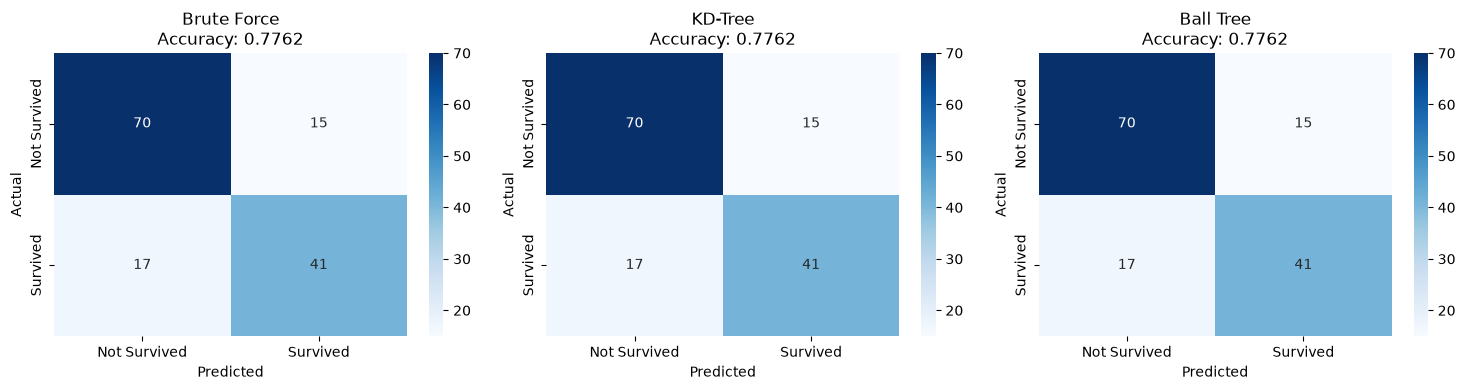

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, data) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, data['preds'])
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        ax=ax,
        xticklabels=['Not Survived', 'Survived'],
        yticklabels=['Not Survived', 'Survived']
    )
    ax.set_title(f"{name}\nAccuracy: {data['acc']:.4f}")
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.show()

k=1    accuracy=0.7203
k=3    accuracy=0.7762
k=5    accuracy=0.7762
k=7    accuracy=0.7902
k=11   accuracy=0.7902
k=15   accuracy=0.8182
k=21   accuracy=0.7762


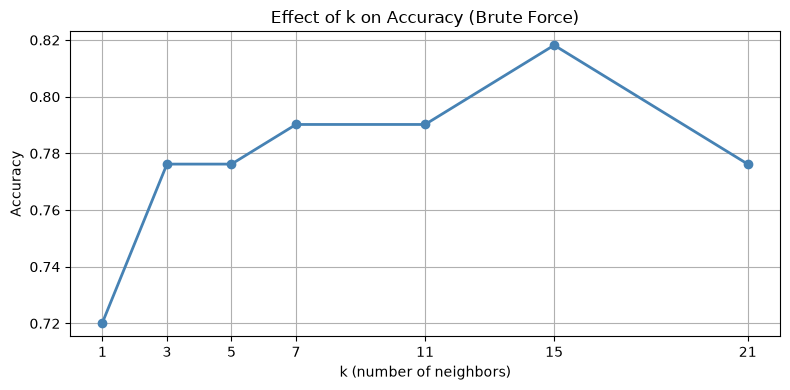

In [7]:
k_values = [1, 3, 5, 7, 11, 15, 21]
accuracies = []

for k in k_values:
    m = KNeighborsClassifier(n_neighbors=k, algorithm='brute')
    m.fit(X_train_scaled, y_train)
    acc = accuracy_score(y_test, m.predict(X_test_scaled))
    accuracies.append(acc)
    print(f"k={k:<3}  accuracy={acc:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(k_values, accuracies, marker='o', color='steelblue', linewidth=2)
plt.title('Effect of k on Accuracy (Brute Force)')
plt.xlabel('k (number of neighbors)')
plt.ylabel('Accuracy')
plt.xticks(k_values)
plt.grid(True)
plt.tight_layout()
plt.show()

In [8]:
print("Summary")
print("=" * 40)
for name, data in results.items():
    print(f"{name:<14}  Accuracy: {data['acc']:.4f}")

print("""
Key observations:
- All three algorithms produce the same accuracy
- Algorithm choice affects speed, not output
- k value has more impact on accuracy than algorithm
- Scaling is essential — without it kNN breaks
""")

Summary
Brute Force     Accuracy: 0.7762
KD-Tree         Accuracy: 0.7762
Ball Tree       Accuracy: 0.7762

Key observations:
- All three algorithms produce the same accuracy
- Algorithm choice affects speed, not output
- k value has more impact on accuracy than algorithm
- Scaling is essential — without it kNN breaks

